<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/01_Langchain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langgraph python-dotenv notebook

In [3]:
from typing import TypedDict

class PortfolioState(TypedDict):
  amountUSD : float
  totalUSD : float
  amountINR : float

In [20]:
def calc_total(state: PortfolioState):
  state.totalUSD = state.amountUSD * 1.03

In [21]:
def calc_convert_to_inr(state: PortfolioState):
  state.amountINR = state.amountUSD * 95

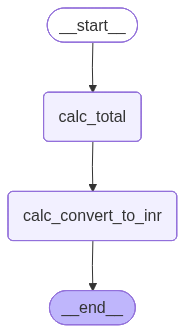

In [27]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)
builder.add_node("calc_total", calc_total)
builder.add_node("calc_convert_to_inr", calc_convert_to_inr)

builder.add_edge(START, "calc_total")
builder.add_edge("calc_total", "calc_convert_to_inr")
builder.add_edge("calc_convert_to_inr", END)
builder.compile()
